# Your Robot's First Steps — Solution

This notebook contains the reference solutions for all exercises.

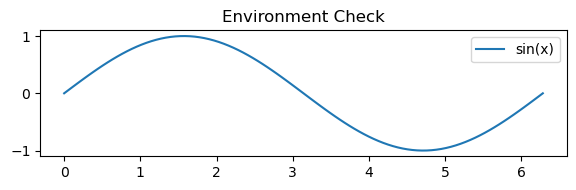

NumPy version: 2.3.3
Environment is ready.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils import (
    DIRECTION_VECTORS,
    FORWARD,
    TURN_LEFT,
    TURN_RIGHT,
    setup_matplotlib,
    draw_robot,
    draw_world,
    draw_trajectory,
    is_blocked,
)

# Quick sanity check
x = np.linspace(0, 2 * np.pi, 100)
plt.figure(figsize=(6, 2))
plt.plot(x, np.sin(x), label="sin(x)")
plt.title("Environment Check")
plt.legend()
plt.tight_layout()
plt.show()

print(f"NumPy version: {np.__version__}")
print("Environment is ready.")

In [2]:
setup_matplotlib()

### Exercise 1 — Solution

In [3]:
def create_robot(x: int, y: int, theta: int) -> np.ndarray:
    state = np.array([x, y, theta])
    return state

In [4]:
s = create_robot(1, 2, 90)
assert isinstance(s, np.ndarray), "Return type must be np.ndarray"
assert s.shape == (3,), f"Expected shape (3,), got {s.shape}"
assert np.array_equal(s, [1, 2, 90]), f"Expected [1, 2, 90], got {s}"
print("Passed.")

Passed.


### Exercise 2 — Solution

In [5]:
def draw_multiple_robots(states: list[np.ndarray], grid_size: int = 7) -> None:
    fig, ax = plt.subplots(figsize=(6, 6))
    blank_world = np.zeros((grid_size, grid_size), dtype=int)
    draw_world(blank_world, ax)

    for state in states:
        draw_robot(state, ax)

    ax.set_title("Multiple robots on the grid")
    plt.tight_layout()
    plt.show()

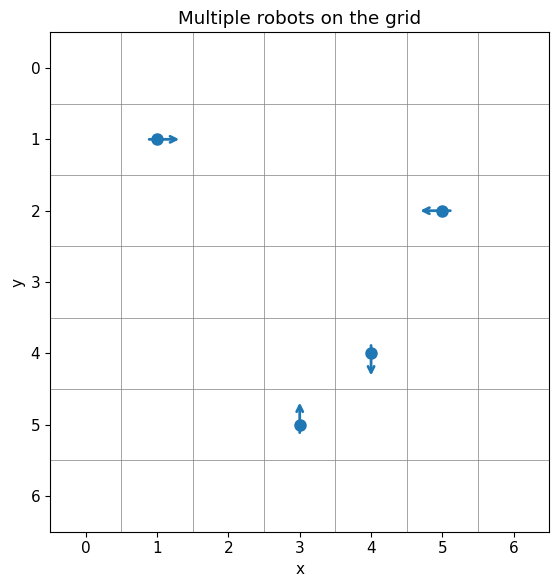

In [6]:
robots = [
    create_robot(1, 1, 0),
    create_robot(3, 5, 90),
    create_robot(5, 2, 180),
    create_robot(4, 4, 270),
]
draw_multiple_robots(robots)

### Exercise 3 — Solution

In [7]:
def act(state: np.ndarray, action: int) -> np.ndarray:
    x, y, theta = state

    if action == FORWARD:
        dx, dy = DIRECTION_VECTORS[theta % 360]
        new_x = x + dx
        new_y = y + dy
        return np.array([new_x, new_y, theta])

    elif action == TURN_LEFT:
        new_theta = (theta + 90) % 360
        return np.array([x, y, new_theta])

    elif action == TURN_RIGHT:
        new_theta = (theta - 90) % 360
        return np.array([x, y, new_theta])

    else:
        raise ValueError(f"Unknown action: {action}")

In [8]:
s0 = create_robot(2, 3, 0)
assert np.array_equal(act(s0, FORWARD), [3, 3, 0])
assert np.array_equal(act(s0, TURN_LEFT), [2, 3, 90])
assert np.array_equal(act(create_robot(2, 3, 0), TURN_RIGHT), [2, 3, 270])
assert act(create_robot(0, 0, 0), TURN_RIGHT)[2] == 270
print("All act() tests passed.")

All act() tests passed.


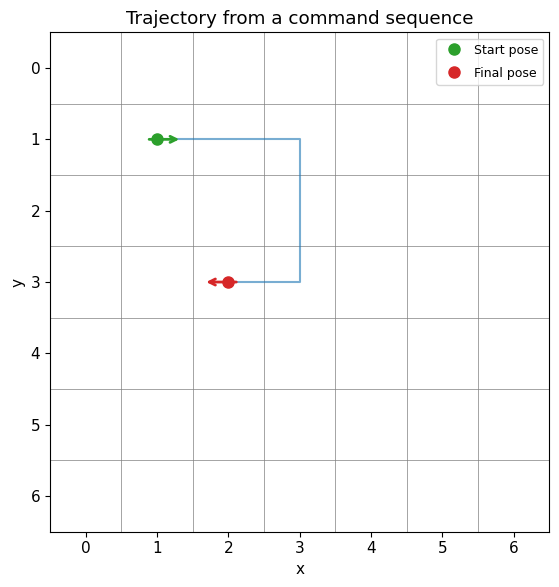

In [9]:
commands = [FORWARD, FORWARD, TURN_RIGHT, FORWARD, FORWARD, TURN_RIGHT, FORWARD]

state = create_robot(1, 1, 0)
trajectory = [state.copy()]
for cmd in commands:
    state = act(state, cmd)
    trajectory.append(state.copy())

fig, ax = plt.subplots(figsize=(6, 6))
blank = np.zeros((7, 7), dtype=int)
draw_trajectory(trajectory, blank, ax)
ax.set_title("Trajectory from a command sequence")
plt.tight_layout()
plt.show()

### Exercise 4 — Solution

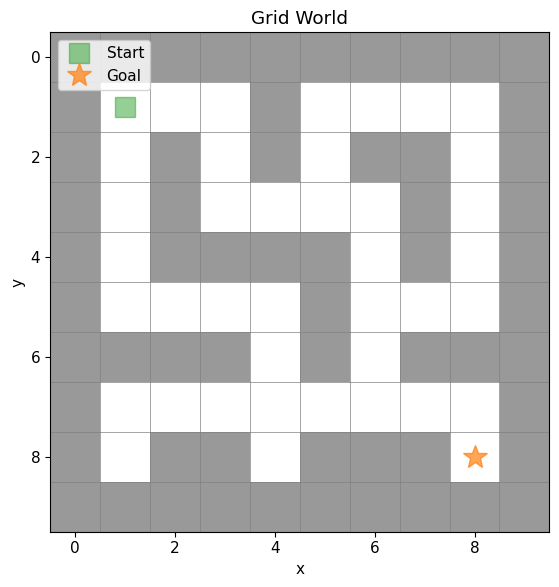

In [10]:
# fmt: off
WORLD = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 1, 0, 1],
    [1, 0, 1, 1, 1, 1, 0, 1, 0, 1],
    [1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 1, 1, 1, 0, 1, 0, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 1, 1, 0, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
], dtype=int)
# fmt: on


START = (1, 1)
GOAL  = (8, 8)

fig, ax = plt.subplots(figsize=(6, 6))
draw_world(WORLD, ax, start=START, goal=GOAL)
ax.set_title("Grid World")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
def perceive(state: np.ndarray, world: np.ndarray) -> dict[str, bool]:
    x, y, theta = int(state[0]), int(state[1]), int(state[2])

    fdx, fdy = DIRECTION_VECTORS[theta % 360]
    front_blocked = is_blocked(x + fdx, y + fdy, world)

    left_theta = (theta + 90) % 360
    ldx, ldy = DIRECTION_VECTORS[left_theta]
    left_blocked = is_blocked(x + ldx, y + ldy, world)

    right_theta = (theta - 90) % 360
    rdx, rdy = DIRECTION_VECTORS[right_theta]
    right_blocked = is_blocked(x + rdx, y + rdy, world)

    return {"front": front_blocked, "left": left_blocked, "right": right_blocked}

In [12]:
test_state = create_robot(1, 1, 0)
sensors = perceive(test_state, WORLD)
print(f"Robot at (1,1) facing East: {sensors}")

assert isinstance(sensors, dict)
assert set(sensors.keys()) == {"front", "left", "right"}

s2 = create_robot(1, 2, 90)
sensors2 = perceive(s2, WORLD)
print(f"Robot at (1,2) facing North: {sensors2}")

print("perceive() structure tests passed.")

Robot at (1,1) facing East: {'front': False, 'left': True, 'right': False}
Robot at (1,2) facing North: {'front': False, 'left': True, 'right': True}
perceive() structure tests passed.


### Exercise 5 — Solution

In [13]:
def reason(sensors: dict[str, bool]) -> int:
    if not sensors["front"]:
        return FORWARD
    elif not sensors["right"]:
        return TURN_RIGHT
    else:
        return TURN_LEFT

In [14]:
assert reason({"front": False, "left": False, "right": False}) == FORWARD
assert reason({"front": True, "left": True, "right": False}) == TURN_RIGHT
assert reason({"front": True, "left": False, "right": True}) == TURN_LEFT
assert reason({"front": True, "left": True, "right": True}) == TURN_LEFT
print("All reason() tests passed.")

All reason() tests passed.


### Exercise 6 — Solution

In [15]:
def run_pra_loop(start_state: np.ndarray, world: np.ndarray, goal: tuple[int, int], n_steps: int = 50) -> list[np.ndarray]:
    state = start_state.copy()
    trajectory = [state.copy()]

    for _ in range(n_steps):
        if int(state[0]) == goal[0] and int(state[1]) == goal[1]:
            break

        sensors = perceive(state, world)
        action = reason(sensors)
        new_state = act(state, action)

        nx, ny = int(new_state[0]), int(new_state[1])
        if not is_blocked(nx, ny, world):
            state = new_state
        else:
            if action != FORWARD:
                state = new_state

        trajectory.append(state.copy())

    return trajectory

In [16]:
initial_state = create_robot(START[0], START[1], 0)
trajectory = run_pra_loop(initial_state, WORLD, goal=GOAL, n_steps=50)

print(f"Trajectory length: {len(trajectory)} states")
print(f"Start : ({trajectory[0][0]:.0f}, {trajectory[0][1]:.0f})")
print(f"Final : ({trajectory[-1][0]:.0f}, {trajectory[-1][1]:.0f})")

Trajectory length: 36 states
Start : (1, 1)
Final : (8, 8)


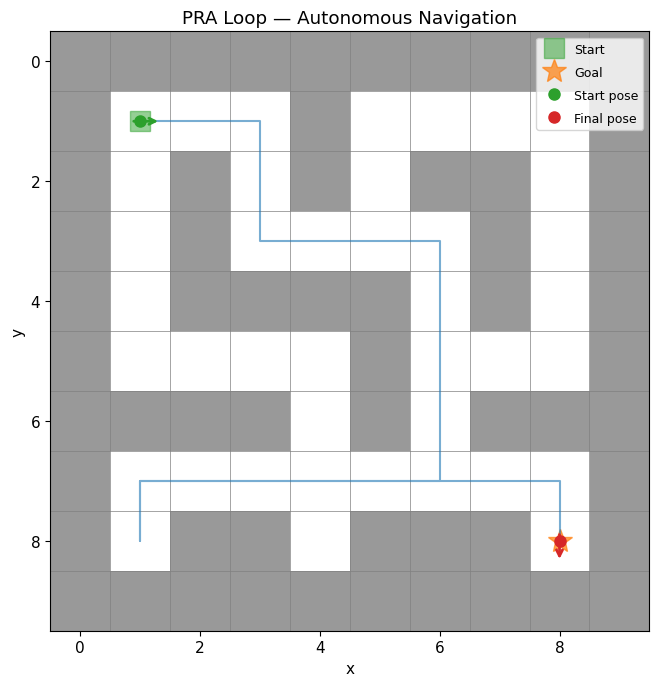

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))
draw_trajectory(trajectory, WORLD, ax, start=START, goal=GOAL)
ax.set_title("PRA Loop — Autonomous Navigation")
plt.tight_layout()
plt.show()

### Bonus — Exploration with visit-count memory

The baseline greedy policy (forward > right > left) happens to solve this maze, but it has no memory — it could easily loop in a different layout. A smarter strategy keeps track of how often each cell has been visited and steers toward **least-visited** neighbours. This is a simple form of exploration that avoids cycles even in mazes with internal wall islands (where classic wall-following fails).

In [18]:
def reason_v2(sensors: dict[str, bool], state: np.ndarray, memory: dict) -> int:
    """Exploration-based: among free neighbours, prefer the least-visited cell.
    Ties are broken by FORWARD > TURN_RIGHT > TURN_LEFT so the robot
    advances when possible rather than spinning in place."""

    x, y, theta = int(state[0]), int(state[1]), int(state[2])

    candidates = []  # (visit_count, tiebreaker, action)

    if not sensors["front"]:
        dx, dy = DIRECTION_VECTORS[theta % 360]
        candidates.append((memory.get((x + dx, y + dy), 0), 0, FORWARD))

    if not sensors["right"]:
        dx, dy = DIRECTION_VECTORS[(theta - 90) % 360]
        candidates.append((memory.get((x + dx, y + dy), 0), 1, TURN_RIGHT))

    if not sensors["left"]:
        dx, dy = DIRECTION_VECTORS[(theta + 90) % 360]
        candidates.append((memory.get((x + dx, y + dy), 0), 2, TURN_LEFT))

    if candidates:
        candidates.sort()
        return candidates[0][2]

    return TURN_LEFT  # dead end — turn around

Baseline:    36 states, final (8, 8)
Exploration: 98 states, final (8, 8)


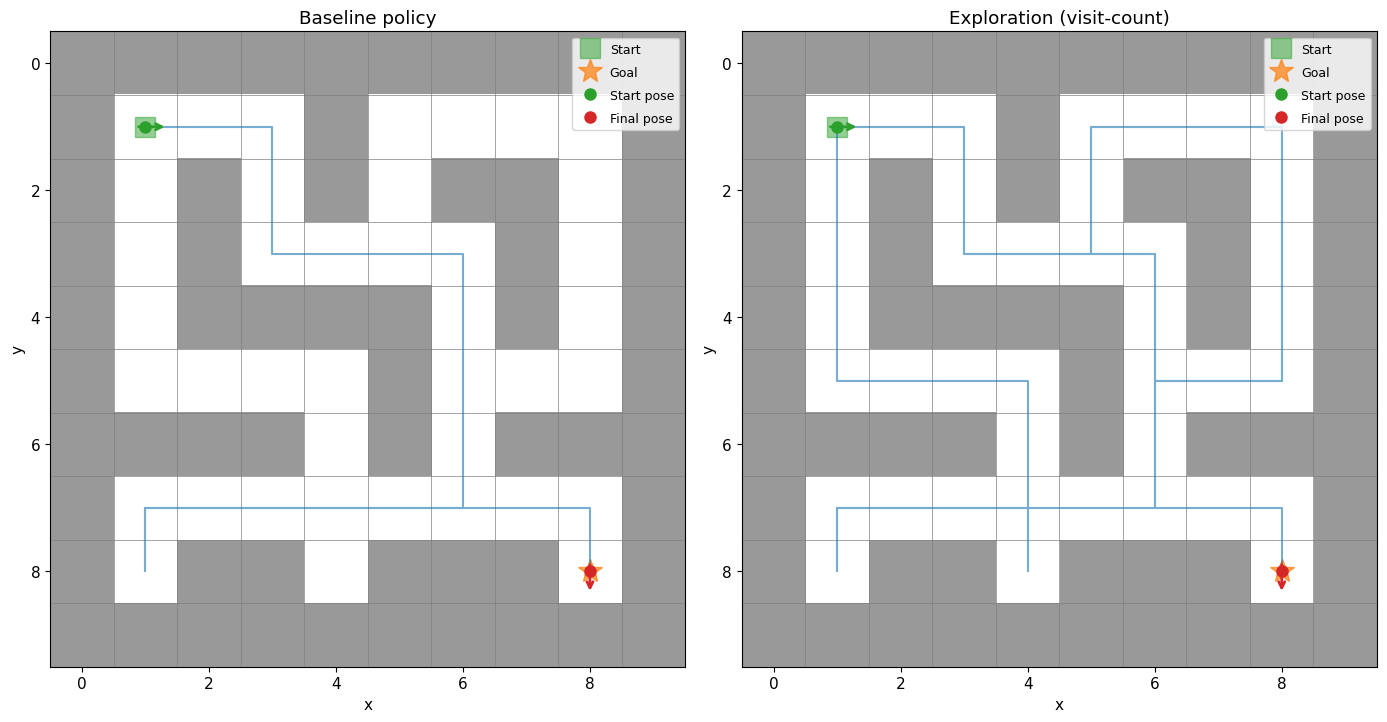

In [19]:
def run_pra_loop_v2(start_state: np.ndarray, world: np.ndarray, goal: tuple[int, int], n_steps: int = 200) -> list[np.ndarray]:
    state = start_state.copy()
    trajectory = [state.copy()]
    memory = {(int(state[0]), int(state[1])): 1}

    for _ in range(n_steps):
        if int(state[0]) == goal[0] and int(state[1]) == goal[1]:
            break

        sensors = perceive(state, world)
        action = reason_v2(sensors, state, memory)
        new_state = act(state, action)

        prev_pos = (int(state[0]), int(state[1]))
        nx, ny = int(new_state[0]), int(new_state[1])
        if not is_blocked(nx, ny, world):
            state = new_state
        else:
            if action != FORWARD:
                state = new_state

        new_pos = (int(state[0]), int(state[1]))
        if new_pos != prev_pos:
            memory[new_pos] = memory.get(new_pos, 0) + 1

        trajectory.append(state.copy())

    return trajectory


traj_v2 = run_pra_loop_v2(create_robot(START[0], START[1], 0), WORLD, goal=GOAL, n_steps=200)

print(f"Baseline:    {len(trajectory)} states, final ({trajectory[-1][0]:.0f}, {trajectory[-1][1]:.0f})")
print(f"Exploration: {len(traj_v2)} states, final ({traj_v2[-1][0]:.0f}, {traj_v2[-1][1]:.0f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
draw_trajectory(trajectory, WORLD, axes[0], start=START, goal=GOAL)
axes[0].set_title("Baseline policy")
draw_trajectory(traj_v2, WORLD, axes[1], start=START, goal=GOAL)
axes[1].set_title("Exploration (visit-count)")
plt.tight_layout()
plt.show()